isoFLOPs v2 rows: 90


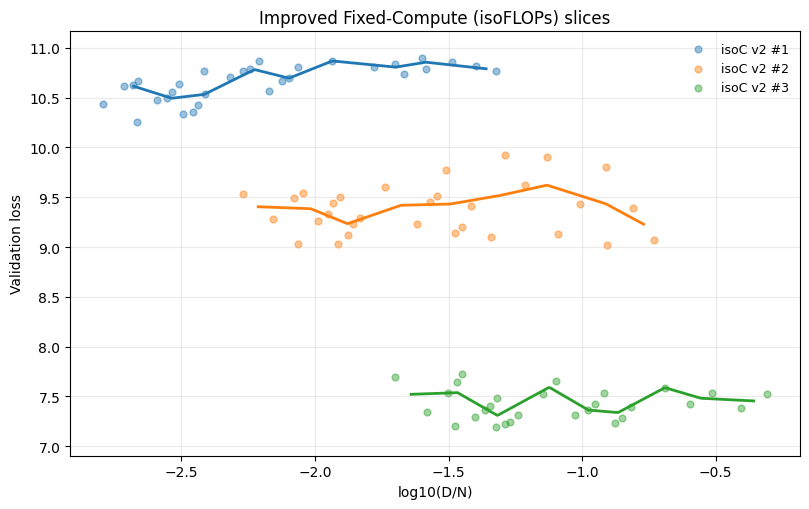

iso-mu v2 rows: 122


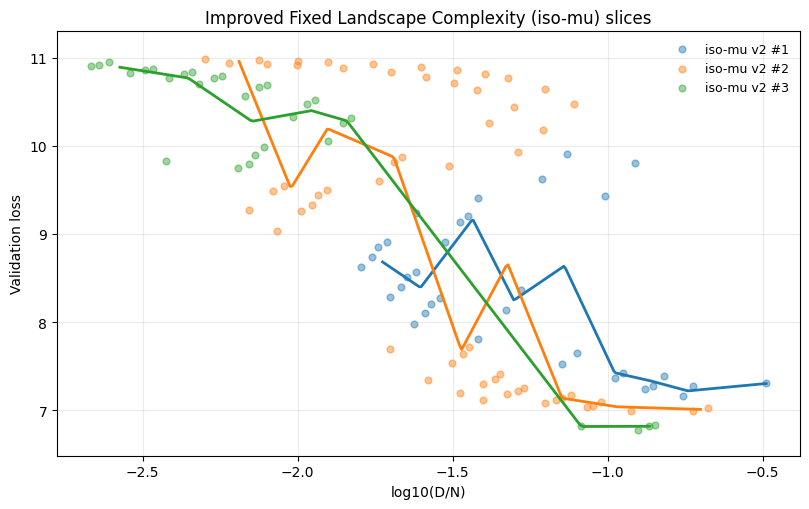

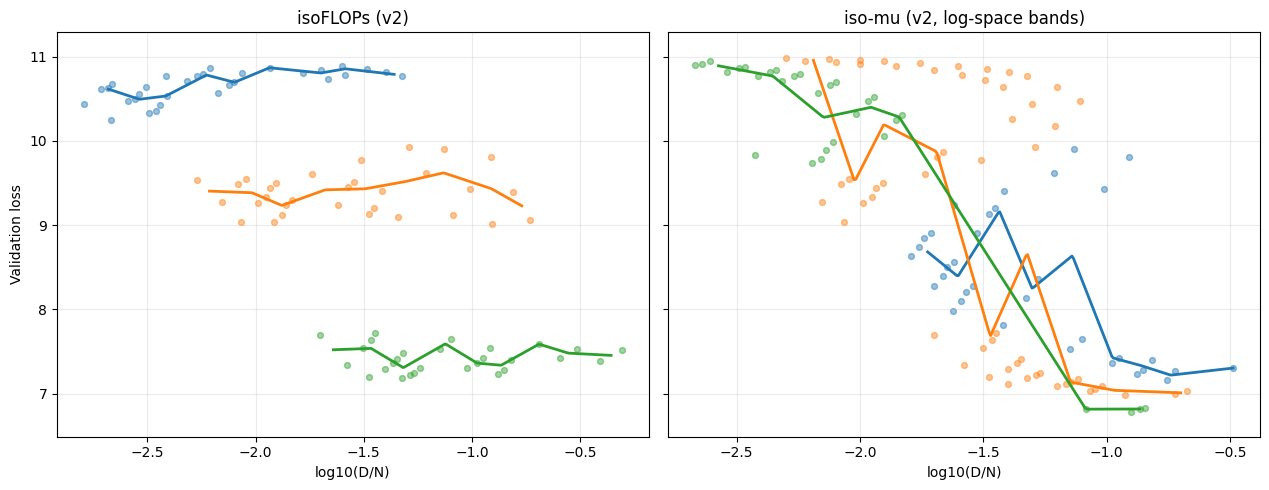

In [1]:
# --- Improved iso-slices (v2): adaptive bands + log-mu slices ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == 'code' else Path.cwd().resolve()
artifacts = root / 'artifacts' / 'results_grid.csv'
figures_dir = root / 'paper' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(artifacts)

# Aggregate over seeds for cleaner slices
agg = (
    df.groupby(['n_params', 'train_tokens_real'], as_index=False)
      .agg(
          val_loss=('val_loss', 'mean'),
          mu=('mu_landscape', 'mean'),
          flops=('flops_estimate', 'mean'),
      )
)
agg['ratio'] = agg['train_tokens_real'] / agg['n_params']
agg['log_ratio'] = np.log10(agg['ratio'])
agg['logC'] = np.log10(agg['flops'])
agg['log_mu'] = np.log10(np.clip(agg['mu'].values, 1e-12, None))


def adaptive_band(data: pd.DataFrame, col: str, center: float, min_points: int = 28, start_hw: float = 0.06, max_hw: float = 0.26, step: float = 0.01) -> pd.DataFrame:
    hw = start_hw
    while hw <= max_hw + 1e-12:
        sub = data[np.abs(data[col] - center) <= hw].copy()
        if len(sub) >= min_points:
            return sub
        hw += step
    return data[np.abs(data[col] - center) <= max_hw].copy()


def robust_trend_xy(g: pd.DataFrame, bins_count: int = 9):
    g = g.sort_values('log_ratio').copy()
    if len(g) < 8:
        return np.array([]), np.array([])
    bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), bins_count)
    if np.unique(bins).size < 3:
        return np.array([]), np.array([])
    g['bin'] = pd.cut(g['log_ratio'], bins=bins, include_lowest=True)
    med = (
        g.groupby('bin', observed=False)
         .agg(x=('log_ratio', 'median'), y=('val_loss', 'median'))
         .dropna()
         .sort_values('x')
    )
    if len(med) < 4:
        return np.array([]), np.array([])
    x = med['x'].to_numpy()
    y = med['y'].to_numpy()
    x_dense = np.linspace(x.min(), x.max(), 200)
    y_dense = np.interp(x_dense, x, y)  # stable shape without forced parabola artifacts
    return x_dense, y_dense


# ------------------------
# v2 isoFLOPs
# ------------------------
levels_count = 3
c_levels = np.quantile(agg['logC'], [0.2, 0.5, 0.8]) if levels_count == 3 else np.quantile(agg['logC'], np.linspace(0.2, 0.8, levels_count))
rows = []
for i, c0 in enumerate(c_levels, start=1):
    sub = adaptive_band(agg, col='logC', center=float(c0), min_points=28, start_hw=0.06, max_hw=0.26, step=0.01)
    if len(sub) < 8:
        continue
    sub['iso_id'] = i
    rows.append(sub)
iso_v2 = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print('isoFLOPs v2 rows:', len(iso_v2))

fig, ax = plt.subplots(figsize=(8.2, 5.2))
if len(iso_v2) == 0:
    print('No isoFLOPs v2 bands found.')
else:
    cmap = plt.get_cmap('tab10')
    for iso_id, g in iso_v2.groupby('iso_id'):
        color = cmap((iso_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.45, label=f'isoC v2 #{iso_id}')
        xs, ys = robust_trend_xy(g, bins_count=10)
        if xs.size:
            ax.plot(xs, ys, color=color, lw=2.0)

    ylo = np.nanpercentile(iso_v2['val_loss'], 1)
    yhi = np.nanpercentile(iso_v2['val_loss'], 99)
    pad = max(0.05, 0.08 * (yhi - ylo))
    ax.set_ylim(ylo - pad, yhi + pad)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation loss')
ax.set_title('Improved Fixed-Compute (isoFLOPs) slices')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_isoflops_slices_v2.png', dpi=240, bbox_inches='tight')
plt.show()


# ------------------------
# v2 iso-mu in log-space
# ------------------------
mu_levels_count = 3
m_levels = np.quantile(agg['log_mu'], [0.2, 0.5, 0.8]) if mu_levels_count == 3 else np.quantile(agg['log_mu'], np.linspace(0.2, 0.8, mu_levels_count))
rows_mu = []
for i, m0 in enumerate(m_levels, start=1):
    sub = adaptive_band(agg, col='log_mu', center=float(m0), min_points=28, start_hw=0.045, max_hw=0.18, step=0.01)
    if len(sub) < 8:
        continue
    sub['isomu_id'] = i
    rows_mu.append(sub)
isomu_v2 = pd.concat(rows_mu, ignore_index=True) if rows_mu else pd.DataFrame()
print('iso-mu v2 rows:', len(isomu_v2))

fig, ax = plt.subplots(figsize=(8.2, 5.2))
if len(isomu_v2) == 0:
    print('No iso-mu v2 bands found.')
else:
    cmap = plt.get_cmap('tab10')
    for band_id, g in isomu_v2.groupby('isomu_id'):
        color = cmap((band_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.45, label=f'iso-mu v2 #{band_id}')
        xs, ys = robust_trend_xy(g, bins_count=10)
        if xs.size:
            ax.plot(xs, ys, color=color, lw=2.0)

    ylo = np.nanpercentile(isomu_v2['val_loss'], 1)
    yhi = np.nanpercentile(isomu_v2['val_loss'], 99)
    pad = max(0.05, 0.08 * (yhi - ylo))
    ax.set_ylim(ylo - pad, yhi + pad)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation loss')
ax.set_title('Improved Fixed Landscape Complexity (iso-mu) slices')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_isomu_slices_v2.png', dpi=240, bbox_inches='tight')
plt.show()


# ------------------------
# v2 side-by-side
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0), sharey=True)
cmap = plt.get_cmap('tab10')

if len(iso_v2) > 0:
    for iso_id, g in iso_v2.groupby('iso_id'):
        color = cmap((iso_id - 1) % 10)
        axes[0].scatter(g['log_ratio'], g['val_loss'], color=color, s=18, alpha=0.45)
        xs, ys = robust_trend_xy(g, bins_count=10)
        if xs.size:
            axes[0].plot(xs, ys, color=color, lw=2.0)

if len(isomu_v2) > 0:
    for band_id, g in isomu_v2.groupby('isomu_id'):
        color = cmap((band_id - 1) % 10)
        axes[1].scatter(g['log_ratio'], g['val_loss'], color=color, s=18, alpha=0.45)
        xs, ys = robust_trend_xy(g, bins_count=10)
        if xs.size:
            axes[1].plot(xs, ys, color=color, lw=2.0)

y_parts = []
if len(iso_v2) > 0:
    y_parts.append(iso_v2['val_loss'].to_numpy())
if len(isomu_v2) > 0:
    y_parts.append(isomu_v2['val_loss'].to_numpy())
if y_parts:
    y_all = np.concatenate(y_parts)
    ylo = np.nanpercentile(y_all, 1)
    yhi = np.nanpercentile(y_all, 99)
    pad = max(0.05, 0.08 * (yhi - ylo))
    axes[0].set_ylim(ylo - pad, yhi + pad)

axes[0].set_title('isoFLOPs (v2)')
axes[1].set_title('iso-mu (v2, log-space bands)')
for ax in axes:
    ax.set_xlabel('log10(D/N)')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('Validation loss')

fig.tight_layout()
fig.savefig(figures_dir / 'exp03_compare_isoflops_vs_isomu_v2.png', dpi=240, bbox_inches='tight')
plt.show()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams['figure.figsize'] = (8.5, 6.0)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

In [3]:
root = Path('..').resolve()
figures_dir = root / 'paper' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(root / 'artifacts' / 'results_grid.csv')

agg = (
    df.groupby(['n_params', 'train_tokens_real'], as_index=False)
      .agg(
          val_loss=('val_loss', 'mean'),
          val_loss_std=('val_loss', 'std'),
          mu=('mu_landscape', 'mean'),
          mu_std=('mu_landscape', 'std'),
          flops=('flops_estimate', 'mean'),
          seeds=('seed', 'count'),
      )
)

agg['ratio'] = agg['train_tokens_real'] / agg['n_params']
agg['log_ratio'] = np.log10(agg['ratio'])
agg['logC'] = np.log10(agg['flops'])

print('raw rows:', len(df), 'agg points:', len(agg))
agg.head()

raw rows: 456 agg points: 228


,n_params,train_tokens_real,val_loss,val_loss_std,mu,mu_std,flops,seeds,ratio,log_ratio,logC
0,6540032,32768,10.980188,0.010439,0.003611,0.000233,1.285823e+12,2,0.005010,-2.300130,12.109181
1,6540032,49152,10.969293,0.011084,0.003490,0.000061,1.928734e+12,2,0.007516,-2.124039,12.285272
2,6540032,65536,10.958841,0.011703,0.003478,0.000098,2.571645e+12,2,0.010021,-1.999100,12.410211
3,6540032,81920,10.948647,0.012767,0.003450,0.000045,3.214557e+12,2,0.012526,-1.902190,12.507121
4,6540032,114688,10.927628,0.014839,0.003450,0.000013,4.500379e+12,2,0.017536,-1.756062,12.653249


isoFLOPs rows: 96


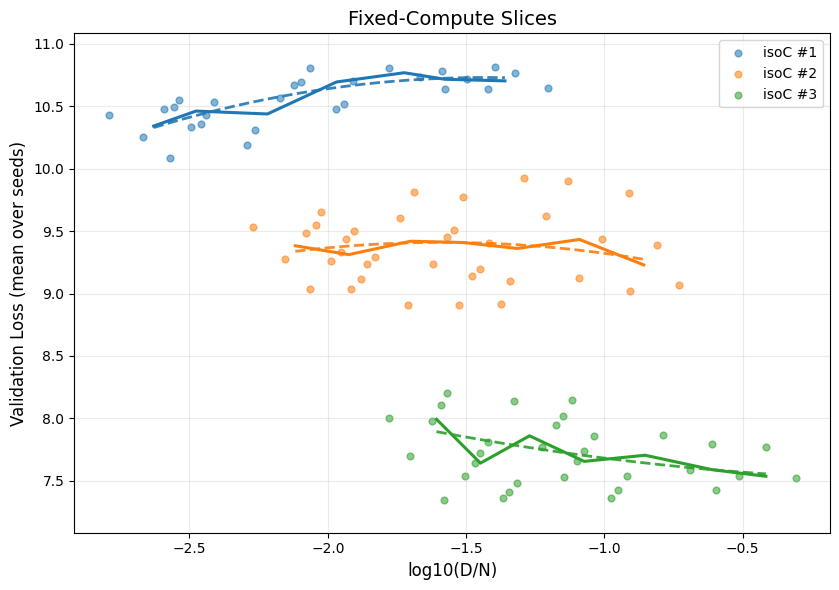

In [4]:
# Kaplan / Chinchilla style: val_loss vs log(D/N) inside isoFLOPs bands
# Use central quantiles and moderate width for stable, interpretable slices.
levels_count = 3
band_halfwidth = 0.14

c_levels = np.quantile(agg['logC'], np.linspace(0.25, 0.75, levels_count))
rows = []
for i, c0 in enumerate(c_levels, start=1):
    sub = agg[np.abs(agg['logC'] - c0) <= band_halfwidth].copy()
    if len(sub) < 6:
        continue
    sub['iso_id'] = i
    sub['logC_center'] = c0
    rows.append(sub)

iso = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print('isoFLOPs rows:', len(iso))

fig, ax = plt.subplots(figsize=(8.5, 6.0))
if len(iso) == 0:
    print('No isoFLOPs bands found, increase band_halfwidth.')
else:
    cmap = plt.get_cmap('tab10')
    for iso_id, g in iso.groupby('iso_id'):
        g = g.sort_values('log_ratio')
        color = cmap((iso_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.55, label=f'isoC #{iso_id}')
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                ax.plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.2)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                ax.plot(xx, yy, '--', color=color, alpha=0.9, linewidth=2.0)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation Loss (mean over seeds)')
ax.set_title('Fixed-Compute Slices')
if len(iso) > 0:
    ylo = np.nanpercentile(iso['val_loss'], 1)
    yhi = np.nanpercentile(iso['val_loss'], 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    ax.set_ylim(ylo - pad, yhi + pad)
ax.legend(ncol=1, loc='upper right')
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_kaplan_u_curves.png', dpi=240, bbox_inches='tight')
plt.show()

iso-mu rows: 383


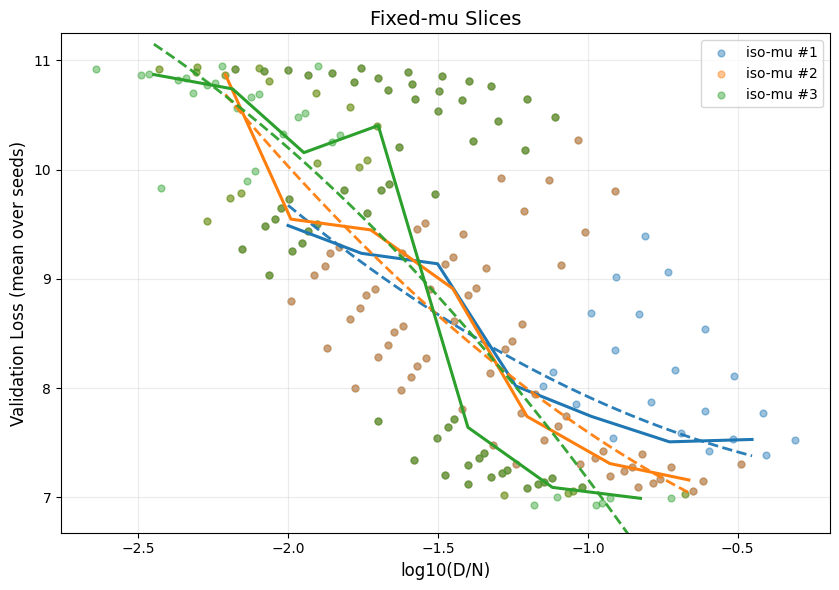

In [5]:
# iso-mu analog: val_loss vs log(D/N) inside fixed-mu bands
# Central quantiles and moderate width improve stability.
mu_levels_count = 3
mu_band_halfwidth = 0.0015

mu_levels = np.quantile(agg['mu'], np.linspace(0.25, 0.75, mu_levels_count))
rows_mu = []
for i, m0 in enumerate(mu_levels, start=1):
    sub = agg[np.abs(agg['mu'] - m0) <= mu_band_halfwidth].copy()
    if len(sub) < 6:
        continue
    # Trim extreme tails to reduce visually destabilizing outliers in main figure
    q_low, q_high = sub['val_loss'].quantile([0.05, 0.95])
    sub = sub[(sub['val_loss'] >= q_low) & (sub['val_loss'] <= q_high)].copy()
    if len(sub) < 5:
        continue
    sub['isomu_id'] = i
    sub['mu_center'] = m0
    rows_mu.append(sub)

isomu = pd.concat(rows_mu, ignore_index=True) if rows_mu else pd.DataFrame()
print('iso-mu rows:', len(isomu))

fig, ax = plt.subplots(figsize=(8.5, 6.0))
if len(isomu) == 0:
    print('No iso-mu bands found, increase mu_band_halfwidth.')
else:
    cmap = plt.get_cmap('tab10')
    for band_id, g in isomu.groupby('isomu_id'):
        g = g.sort_values('log_ratio')
        color = cmap((band_id - 1) % 10)
        ax.scatter(g['log_ratio'], g['val_loss'], color=color, s=24, alpha=0.45, label=f'iso-mu #{band_id}')
        if len(g) >= 8:
            # Robust trend: median-in-bins + quadratic fit on bin centers.
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                ax.plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.2)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                ax.plot(xx, yy, '--', color=color, alpha=0.95, linewidth=2.0)

ax.set_xlabel('log10(D/N)')
ax.set_ylabel('Validation Loss (mean over seeds)')
ax.set_title('Fixed-mu Slices')
if len(isomu) > 0:
    ylo = np.nanpercentile(isomu['val_loss'], 1)
    yhi = np.nanpercentile(isomu['val_loss'], 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    ax.set_ylim(ylo - pad, yhi + pad)
ax.legend(ncol=1, loc='upper right')
fig.tight_layout()
fig.savefig(figures_dir / 'exp03_isomu_slices.png', dpi=240, bbox_inches='tight')
plt.show()

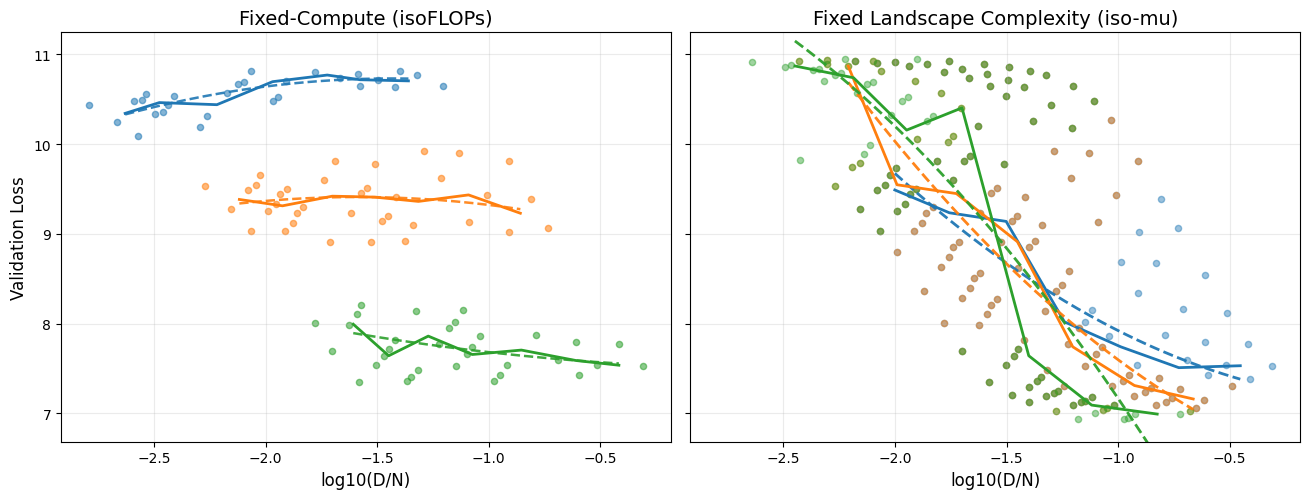

In [6]:
# Side-by-side comparison with identical axes (paper-ready)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1), sharex=True, sharey=True)

# left: isoFLOPs
if len(iso) > 0:
    cmap = plt.get_cmap('tab10')
    for iso_id, g in iso.groupby('iso_id'):
        g = g.sort_values('log_ratio')
        color = cmap((iso_id - 1) % 10)
        axes[0].scatter(g['log_ratio'], g['val_loss'], color=color, s=20, alpha=0.55)
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                axes[0].plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.0)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                axes[0].plot(xx, yy, '--', color=color, alpha=0.9, linewidth=1.8)

axes[0].set_title('Fixed-Compute (isoFLOPs)')
axes[0].set_xlabel('log10(D/N)')
axes[0].set_ylabel('Validation Loss')
if len(iso) > 0 or len(isomu) > 0:
    y_parts = []
    if len(iso) > 0:
        y_parts.append(iso['val_loss'].values)
    if len(isomu) > 0:
        y_parts.append(isomu['val_loss'].values)
    y_all = np.concatenate(y_parts)
    ylo = np.nanpercentile(y_all, 1)
    yhi = np.nanpercentile(y_all, 99)
    pad = 0.08 * (yhi - ylo if yhi > ylo else 1.0)
    axes[0].set_ylim(ylo - pad, yhi + pad)

# right: iso-mu
if len(isomu) > 0:
    cmap = plt.get_cmap('tab10')
    for band_id, g in isomu.groupby('isomu_id'):
        g = g.sort_values('log_ratio')
        color = cmap((band_id - 1) % 10)
        axes[1].scatter(g['log_ratio'], g['val_loss'], color=color, s=20, alpha=0.45)
        if len(g) >= 8:
            bins = np.linspace(g['log_ratio'].min(), g['log_ratio'].max(), 8)
            g2 = g.copy()
            g2['bin'] = pd.cut(g2['log_ratio'], bins=bins, include_lowest=True)
            bmed = g2.groupby('bin', observed=False).agg(
                x=('log_ratio', 'median'),
                y=('val_loss', 'median'),
            ).dropna().sort_values('x')
            if len(bmed) >= 4:
                axes[1].plot(bmed['x'], bmed['y'], '-', color=color, linewidth=2.0)
                x, y = bmed['x'].values, bmed['y'].values
                coefs = np.polyfit(x, y, deg=2)
                xx = np.linspace(x.min(), x.max(), 200)
                yy = np.polyval(coefs, xx)
                axes[1].plot(xx, yy, '--', color=color, alpha=0.95, linewidth=2.0)

axes[1].set_title('Fixed Landscape Complexity (iso-mu)')
axes[1].set_xlabel('log10(D/N)')

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / 'exp03_compare_isoflops_vs_isomu.png', dpi=240, bbox_inches='tight')
plt.show()